# Developer Salary — Exploratory Data Analysis

**Project 2 — Regression** · Machine Learning 1, WNE UW, 2025/2026

In this project we have to predict the annual salary (in USD) of software developers based on their personal details, skills, and work setup. The target column is `annual.pay.usd`. The grading metric on Kaggle is **RMSE** (Root Mean Squared Error).

Before we build any model, we want to look at the data carefully. This notebook is our exploratory data analysis (EDA). We try to answer these questions:

1. How big is the dataset?
2. What does the target (salary) distribution look like? Is it skewed?
3. What kinds of features do we have?
4. Where are the missing values?
5. Which features look like they will help predict salary?
6. What preprocessing do we need before training models?

The answers we find here will guide us when we build models in `02_search.ipynb`.

## Important context

This dataset comes from a survey of software developers (similar in style to the Stack Overflow Developer Survey). Many columns ask the developer to choose multiple options at once — for example, "Which programming languages do you use?" can have answers like `"Python;JavaScript;SQL"`. These multi-value columns need special handling, which we will discuss in detail later.


## 1. Setup and loading the data

We start with the standard imports.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("data")
RANDOM_STATE = 42

In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_sub = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"Train shape:        {train.shape}")
print(f"Test shape:         {test.shape}")
print(f"Sample sub shape:   {sample_sub.shape}")

Train shape:        (2512, 41)
Test shape:         (628, 41)
Sample sub shape:   (628, 2)


The training set has only 2,512 rows but 41 columns. The test set has 628 rows. This is a much **smaller dataset** than the restaurants project, which means we have to be careful about overfitting — with so few rows, complex models can easily memorize the training data and fail on the test set.

The sample submission shows the format we need to use for Kaggle:

In [3]:
sample_sub.head()

,id,annual.pay.usd
0,0,34421.423484
1,1,36049.549887
2,2,81892.252244
3,3,45965.314528
4,4,42360.381217


Two columns: `id` (which the test set has but our training set does not — Kaggle uses it just to match predictions back to rows) and `annual.pay.usd` (the salary prediction in USD, which can be any positive number).

In [4]:
train.head()

,annual.pay.usd,region,age.group,employment.type,work.location,education,is.dev.professional,coding.years.total,coding.years.professional,experience.years,dev.role,company.size,people.manager,industry,tech.purchase.influence,build.vs.buy,side.coding,how.learned.coding,prog.languages,databases,cloud.platforms,web.frameworks,other.tech,dev.tools,dev.environments,personal.os,work.os,project.mgmt.tools,comm.tools,ai.search.tools,ai.tools.used,uses.ai,ai.sentiment,ai.trust,ai.complex.rating,ai.job.threat,daily.search.time,daily.answer.time,cloud.hosting,first.help.source,job.satisfaction
0,44529.0,R11,35-44,Freelance/Self-employed,In-person,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",I am a developer by profession,29.0,16.0,17.0,"Developer, desktop or enterprise applications",2 to 9 employees,Individual contributor,Computer Systems Design and Services,I have a great deal of influence,Is ready-to-go but also customizable for growt...,Bootstrapping a business;Freelance/contract wo...,Books / Physical media;Colleague;Friend or fam...,C++;Dart;Delphi;HTML/CSS;JavaScript;PHP;SQL,Cloud Firestore;Elasticsearch;PostgreSQL;Redis...,NaN,NaN,Flutter;OpenGL,APT;Chocolatey;Make;Webpack;npm,"Android Studio;Netbeans;Rad Studio (Delphi, C+...",Debian;Other Linux-based,Debian;Other Linux-based,NaN,Whatsapp,ChatGPT;Google Gemini;WolframAlpha,Debugging and getting help;Learning about a co...,Yes,Indifferent,Somewhat trust,Very poor at handling complex tasks,No,60-120 minutes a day,15-30 minutes a day,Hybrid (on-prem and cloud),Traditional public search engine,7.0
1,82086.0,R05,35-44,Full-time,Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",I am a developer by profession,17.0,14.0,13.0,"Developer, back-end",20 to 99 employees,Individual contributor,"Internet, Telecomm or Information Services",I have little or no influence,Is ready-to-go but also customizable for growt...,Contribute to open-source projects;Hobby,Books / Physical media;Colleague;Online Course...,Bash/Shell (all shells);HTML/CSS;Java;JavaScri...,Dynamodb;Elasticsearch;H2;MariaDB;MySQL;Postgr...,Amazon Web Services (AWS);OpenShift,AngularJS;Node.js;Spring Boot;jQuery,Quarkus;RabbitMQ;Spring Framework,APT;Ansible;Ant;Docker;Gradle;Homebrew;Kuberne...,IntelliJ IDEA;Vim;Visual Studio Code,Ubuntu,Ubuntu,Confluence;Jira;Miro,Google Meet;Microsoft Teams;Slack,ChatGPT,NaN,"No, and I don't plan to",NaN,NaN,NaN,NaN,30-60 minutes a day,Less than 15 minutes a day,Cloud only (single or multi-cloud),Traditional public search engine,6.0
2,14223.0,R17,18-24,Full-time,Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",I am a developer by profession,4.0,0.0,1.0,"Developer, full-stack",100 to 499 employees,NaN,NaN,I have some influence,Is set up to be customized and needs to be eng...,Freelance/contract work;Professional developme...,On the job training;Online Courses or Certific...,HTML/CSS;JavaScript;Python;TypeScript,Firebase Realtime Database;MongoDB;MySQL;Postg...,Amazon Web Services (AWS);Firebase,Django;FastAPI;Next.js;React;Vue.js,React Native,Docker;Gradle;Make;Pip;Vite;Webpack;Yarn;npm,Android Studio;PyCharm;WebStorm,Windows,Other (please specify):,Confluence;Jira,Slack;Telegram;Zoom,ChatGPT;GitHub Copilot,NaN,Yes,Very favorable,Neither trust nor distrust,NaN,I'm not sure,NaN,NaN,NaN,NaN,10.0
3,78010.0,R17,18-24,Full-time,Remote,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",I am a developer by profession,5.0,6.0,5.0,Academic researcher,100 to 499 employees,Individual contributor,Higher Education,I have some influence,Is set up to be customized and needs to be eng...,School or academic work,"Books / Physical media;School (i.e., Universit...",Java;Python;SQL,Dynamodb;Elasticsearch;MongoDB,Amazon Web Services (AWS),FastAPI;Flask,Apache Kafka;Apache Spark;CUDA;Hadoop;Hugging ...,Docker;Homebrew;Kubernetes;Pip;Terraform,Jupyter Notebook/JupyterLab;Visual Studio Code,MacOS,MacOS,Confluence;Jira;Lucid;Markdown File;Miro;Notio...,NaN,ChatGPT;Claude;Google Gemini;Other;Perplexity ...,Le

## 2. The target variable: annual salary

Let's look at the basic statistics of the salary column.

In [5]:
target = "annual.pay.usd"
print(train[target].describe().round(2))

count       2512.00
mean       49712.96
std       109616.16
min            1.00
25%        16216.75
50%        40828.50
75%        65589.25
max      4773360.00
Name: annual.pay.usd, dtype: float64


The numbers tell an interesting story:

- The **median salary is about $40,000** per year.
- The **mean is $49,700** — much higher than the median, which already tells us the distribution is right-skewed.
- The **minimum is $1** (probably a data entry oddity, or someone reporting near-zero pay).
- The **maximum is $4.77 million** (likely a startup founder or extreme outlier).
- The **standard deviation is $109,600** — almost three times the median, which confirms the data is very spread out.

Let's plot it to see the shape.

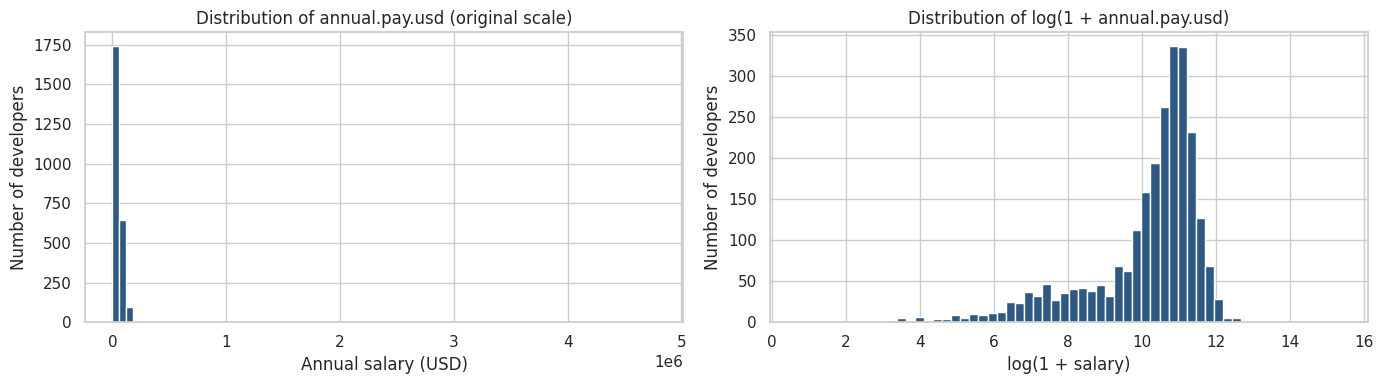

Skewness of target (original):     33.13
Skewness of target (log-transformed): -1.64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train[target], bins=80, color="#2E5984", edgecolor="white")
axes[0].set_title("Distribution of annual.pay.usd (original scale)")
axes[0].set_xlabel("Annual salary (USD)")
axes[0].set_ylabel("Number of developers")

axes[1].hist(np.log1p(train[target]), bins=60, color="#2E5984", edgecolor="white")
axes[1].set_title("Distribution of log(1 + annual.pay.usd)")
axes[1].set_xlabel("log(1 + salary)")
axes[1].set_ylabel("Number of developers")

plt.tight_layout()
plt.show()

print(f"Skewness of target (original):     {train[target].skew():.2f}")
print(f"Skewness of target (log-transformed): {np.log1p(train[target]).skew():.2f}")

### Why this matters — and our log-transform strategy

The original distribution is **extremely right-skewed** (skewness of about 33). A few very high salaries stretch the right tail far beyond where most developers actually earn. This is bad for our models for two reasons:

1. **RMSE penalizes large errors quadratically.** A prediction that is $1M off contributes a million squared to the error sum. The few highest-earning developers would dominate the loss, and the model would chase them at the expense of everyone else.
2. **Linear models assume a roughly normal error distribution.** With a highly skewed target, the assumption breaks and the model is poorly calibrated.

The standard fix is to **predict log(salary) instead of salary directly**. The right plot above shows the log-transformed distribution — almost bell-shaped, much more well-behaved.

In practice, we use scikit-learn's `TransformedTargetRegressor`. It wraps any regressor and:

1. Applies `np.log1p` (which is `log(1+x)`, safer than `log(x)` when values might be zero) to the target before training.
2. Trains the model on the transformed target.
3. Applies `np.expm1` (the inverse of `log1p`) to the predictions before evaluating RMSE.

This way, the model trains in log-space but we still evaluate RMSE on the original USD scale, which is what Kaggle grades us on.

A note on the `$1` and very low values: we considered removing them as outliers, but decided to **keep them**. They might be real (interns, very junior developers, part-time roles in low-cost-of-living regions). The log transform softens their effect, and our regularized models will not be misled by a small number of low-end points.

## 3. What types of features do we have?

This dataset has three main types of columns, and getting the classification right is critical for preprocessing:

1. **Numeric** — straightforward number columns (years of experience, job satisfaction score).
2. **Plain categorical** — text columns with a single value per row (region, education, age group).
3. **Multi-label** — text columns where one cell can hold *multiple* answers separated by semicolons (programming languages, dev tools, etc.).

The third type is special and needs its own preprocessing approach.

In [7]:
from pandas.api.types import is_numeric_dtype

feature_cols = [c for c in train.columns if c != target]
numeric_cols = [c for c in feature_cols if is_numeric_dtype(train[c])]

# Columns where some rows contain semicolons are multi-label
def is_multi_label(series):
    return series.dropna().astype(str).str.contains(";").any()

text_cols = [c for c in feature_cols if c not in numeric_cols]
multi_label_cols = [c for c in text_cols if is_multi_label(train[c])]
plain_cat_cols = [c for c in text_cols if c not in multi_label_cols]

print(f"Numeric features:        {len(numeric_cols)}")
print(f"Plain categorical:       {len(plain_cat_cols)}")
print(f"Multi-label categorical: {len(multi_label_cols)}")
print(f"Total:                   {len(feature_cols)}")

Numeric features:        4
Plain categorical:       21
Multi-label categorical: 15
Total:                   40


In [8]:
print("Numeric columns:")
for c in numeric_cols:
    print(f"  {c:30s} range = {train[c].min():.1f} to {train[c].max():.1f}, missing = {train[c].isna().sum()}")

Numeric columns:
  coding.years.total             range = 0.0 to 49.0, missing = 5
  coding.years.professional      range = 0.0 to 40.0, missing = 11
  experience.years               range = 0.0 to 42.0, missing = 863
  job.satisfaction               range = 0.0 to 10.0, missing = 867


Only four numeric columns: years of coding (total and professional), years of work experience, and a job-satisfaction score from 1-10. Several have missing values, which we will handle with median imputation.

In [9]:
print("Plain categorical columns:")
for c in plain_cat_cols:
    print(f"  {c:30s} unique = {train[c].nunique():3d}, missing = {train[c].isna().sum():4d}")

Plain categorical columns:
  region                         unique =  18, missing =    0
  age.group                      unique =   5, missing =    0
  employment.type                unique =   5, missing =    0
  work.location                  unique =   3, missing =    0
  education                      unique =   8, missing =    0
  is.dev.professional            unique =   2, missing =    0
  dev.role                       unique =  22, missing =    2
  company.size                   unique =  10, missing =    1
  people.manager                 unique =   2, missing =  859
  industry                       unique =  15, missing =  879
  tech.purchase.influence        unique =   3, missing =    7
  build.vs.buy                   unique =   3, missing =  157
  uses.ai                        unique =   3, missing =    0
  ai.sentiment                   unique =   6, missing =  444
  ai.trust                       unique =   5, missing =  771
  ai.complex.rating              unique =  

These are normal categorical columns where each developer has one answer:

- `region` has 18 unique codes (R01 to R18) — likely country/region groupings.
- `age.group` has 5 categories (18-24, 25-34, 35-44, 45-54, 55+).
- `education` has 8 categories (from primary school to PhD).
- `company.size`, `industry`, `dev.role`, etc.

All of these will be one-hot encoded.

In [10]:
print("Multi-label (semicolon-separated) columns:")
print(f"{'Column':<28s} {'unique tokens':<15s} {'avg tokens/row':<15s}")
for col in multi_label_cols:
    series = train[col].dropna().astype(str)
    all_tokens = set()
    total_tokens = 0
    for val in series:
        toks = val.split(";")
        all_tokens.update(toks)
        total_tokens += len(toks)
    avg = total_tokens / len(series) if len(series) > 0 else 0
    print(f"  {col:<28s} {len(all_tokens):<15d} {avg:<15.2f}")

Multi-label (semicolon-separated) columns:
Column                       unique tokens   avg tokens/row 
  side.coding                  8               1.93           
  how.learned.coding           9               3.42           
  prog.languages               40              4.61           
  databases                    29              3.17           
  cloud.platforms              25              2.15           
  web.frameworks               34              3.30           
  other.tech                   37              2.58           
  dev.tools                    34              4.38           
  dev.environments             33              3.17           
  personal.os                  17              1.99           
  work.os                      14              1.82           
  project.mgmt.tools           24              2.78           
  comm.tools                   18              3.46           
  ai.search.tools              16              2.09           
  ai.tools.use

### Why multi-label columns need special treatment

Look at `prog.languages` — a typical row might contain `"Python;SQL;JavaScript;Bash/Shell (all shells);TypeScript"`. There are **1,355 unique combinations** of languages, but only **40 unique individual languages**.

If we used standard one-hot encoding, we would create 1,355 new columns (one per combination) and lose all the information that "Python developer X" and "Python+SQL developer Y" share the same Python skill.

The smart approach is **multi-label binarization**: for each unique token, create one binary column. So `prog.languages` becomes 40 columns: `lang_Python`, `lang_JavaScript`, `lang_SQL`, etc. Each is 1 if the developer listed that language, 0 otherwise.

This is much better because:

1. It captures the **actual skills** the developer has, not just the unique combination.
2. The model can learn "knowing Python is worth +X dollars" and apply it to anyone who lists Python.
3. The resulting binary columns are sparse but informative.

Scikit-learn provides `MultiLabelBinarizer` for this exact purpose. We will use a small custom wrapper (built into a `Pipeline`) to apply it to each of these 15 columns.

**Final dimensionality check** — adding up all the binarized tokens gives us roughly 350-400 extra columns, plus ~120 one-hot columns from plain categoricals and 4 numeric ones. So our model sees about **500 features** on 2,512 training rows. That ratio (4-5 rows per feature) means we will need **strong regularization** to avoid overfitting.

## 4. Missing values

Some columns have a lot of missing values. Let's see which.

In [11]:
missing = train[feature_cols].isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_table = missing_table[missing_table["missing_count"] > 0]

print(f"Columns with at least one missing value: {len(missing_table)}")
missing_table

Columns with at least one missing value: 32


,missing_count,missing_pct
cloud.hosting,900,35.83
daily.answer.time,888,35.35
daily.search.time,886,35.27
first.help.source,883,35.15
industry,879,34.99
job.satisfaction,867,34.51
experience.years,863,34.36
people.manager,859,34.20
other.tech,853,33.96
ai.tools.used,850,33.84


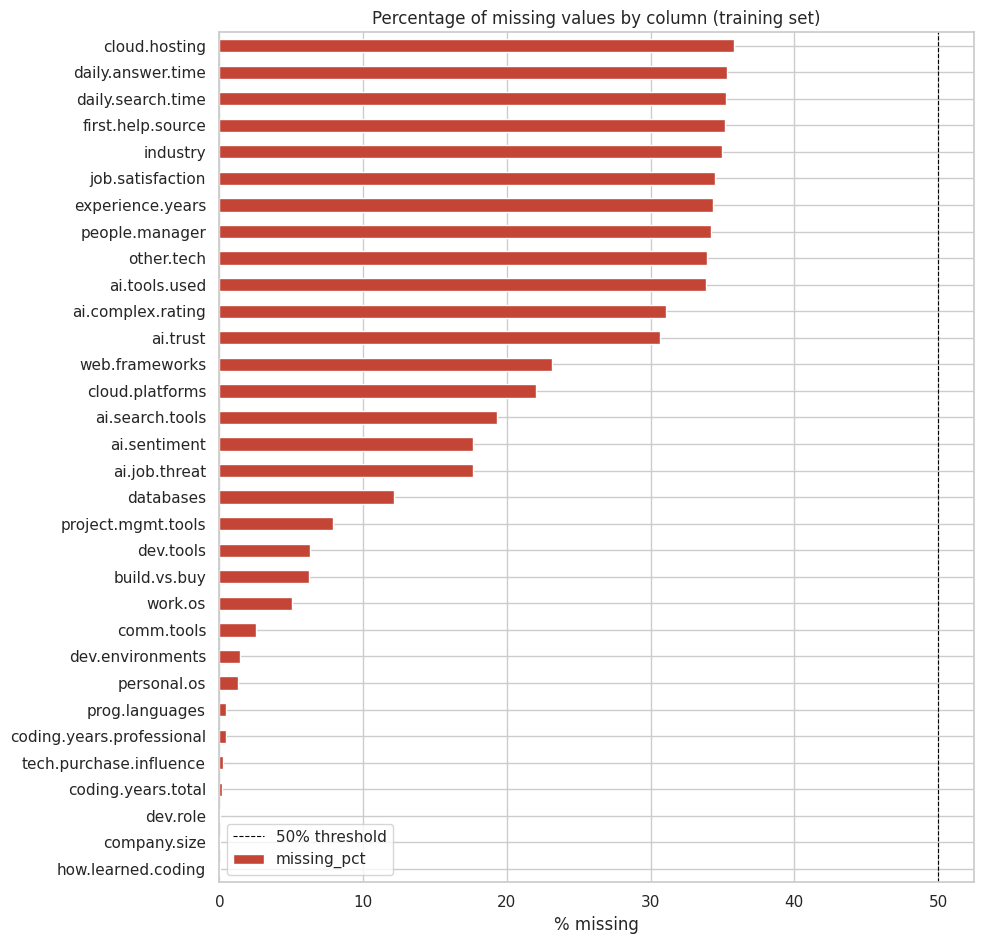

In [12]:
fig, ax = plt.subplots(figsize=(10, max(4, len(missing_table) * 0.3)))
missing_table["missing_pct"].plot(kind="barh", ax=ax, color="#C44536")
ax.invert_yaxis()
ax.set_xlabel("% missing")
ax.set_title("Percentage of missing values by column (training set)")
ax.axvline(50, color="black", linestyle="--", linewidth=0.8, label="50% threshold")
ax.legend()
plt.tight_layout()
plt.show()

### What we see and our strategy

Several patterns:

- **AI-related columns** (`ai.trust`, `ai.complex.rating`, `ai.tools.used`, `daily.search.time`, etc.) have 30-35% missing values. Probably the developers who do not use AI tools skipped those questions.
- **`cloud.hosting`, `first.help.source`, `industry`, `job.satisfaction`** are missing for about a third of respondents.
- **`experience.years`** is missing for 863 rows (34%). This is strange because we also have `coding.years.total` and `coding.years.professional` — there may be redundancy.

Our strategy is the same as in Project 1:

- For **numeric columns**: impute with the median (robust to outliers).
- For **plain categorical**: impute with the most frequent category.
- For **multi-label categorical**: treat missing as "no tokens listed" (an empty set), which is meaningful here — the developer did not answer the question.

We keep all columns even with high missingness. The missing pattern itself might be informative, and our regularized models will handle noisy features.

## 5. Which numeric features predict salary?

We use scatter plots with the log-transformed target. Log-transforming reveals patterns that the heavy right tail would otherwise hide.

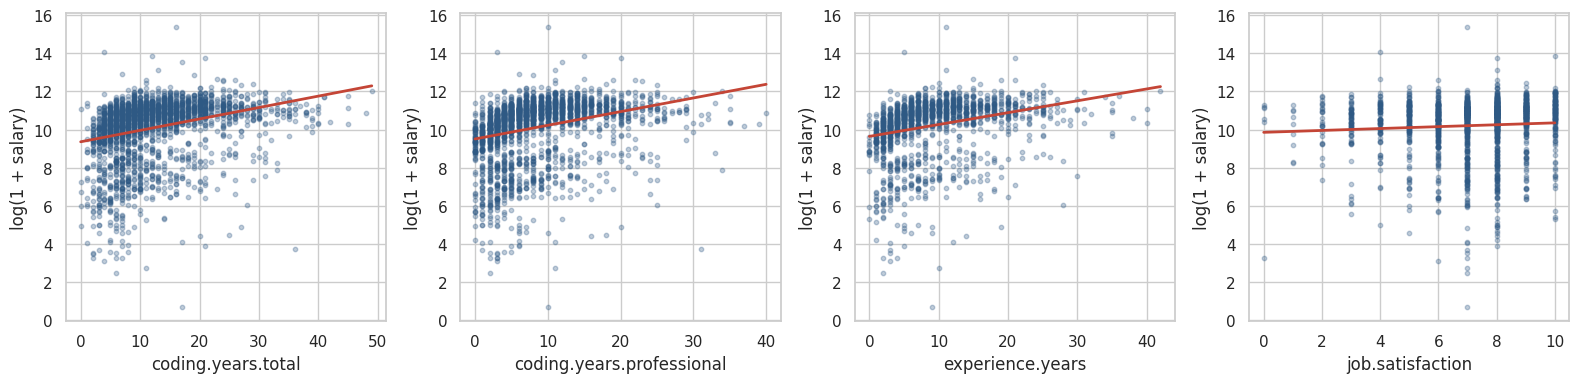

In [13]:
log_target = np.log1p(train[target])

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    ax.scatter(train[col], log_target, alpha=0.3, s=10, color="#2E5984")
    ax.set_xlabel(col)
    ax.set_ylabel("log(1 + salary)")
    # Add a trend line
    valid = train[[col]].dropna().index
    if len(valid) > 50:
        x = train.loc[valid, col].values
        y = log_target.loc[valid].values
        z = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 50)
        ax.plot(x_line, np.poly1d(z)(x_line), color="#C44536", linewidth=2)
plt.tight_layout()
plt.show()

In [14]:
# Numeric correlations with log target
print("Pearson correlation of numeric features with log(salary):")
for c in numeric_cols:
    valid = train[[c]].dropna().index
    corr = train.loc[valid, c].corr(log_target.loc[valid])
    print(f"  {c:30s} {corr:+.3f}")

Pearson correlation of numeric features with log(salary):
  coding.years.total             +0.286
  coding.years.professional      +0.278
  experience.years               +0.273
  job.satisfaction               +0.063


### What we see

All four numeric features show **positive correlation with salary** (red trend lines slope upward). The strongest signals are:

- **`coding.years.professional`** — years of paid coding work. Strong positive effect, which makes sense.
- **`coding.years.total`** — total coding years including hobby/study. Slightly weaker than professional years (a 10-year hobbyist earns less than a 10-year professional).
- **`experience.years`** — general work experience. Also positive.
- **`job.satisfaction`** — interestingly, this has a small positive correlation too. Happier developers tend to earn a bit more, though we cannot tell which way the causation runs.

These are weak-to-moderate signals individually but will contribute jointly in a linear model.

## 6. Which categorical features predict salary?

For categorical variables, we use boxplots of log-salary by category. We focus on the most interpretable ones.

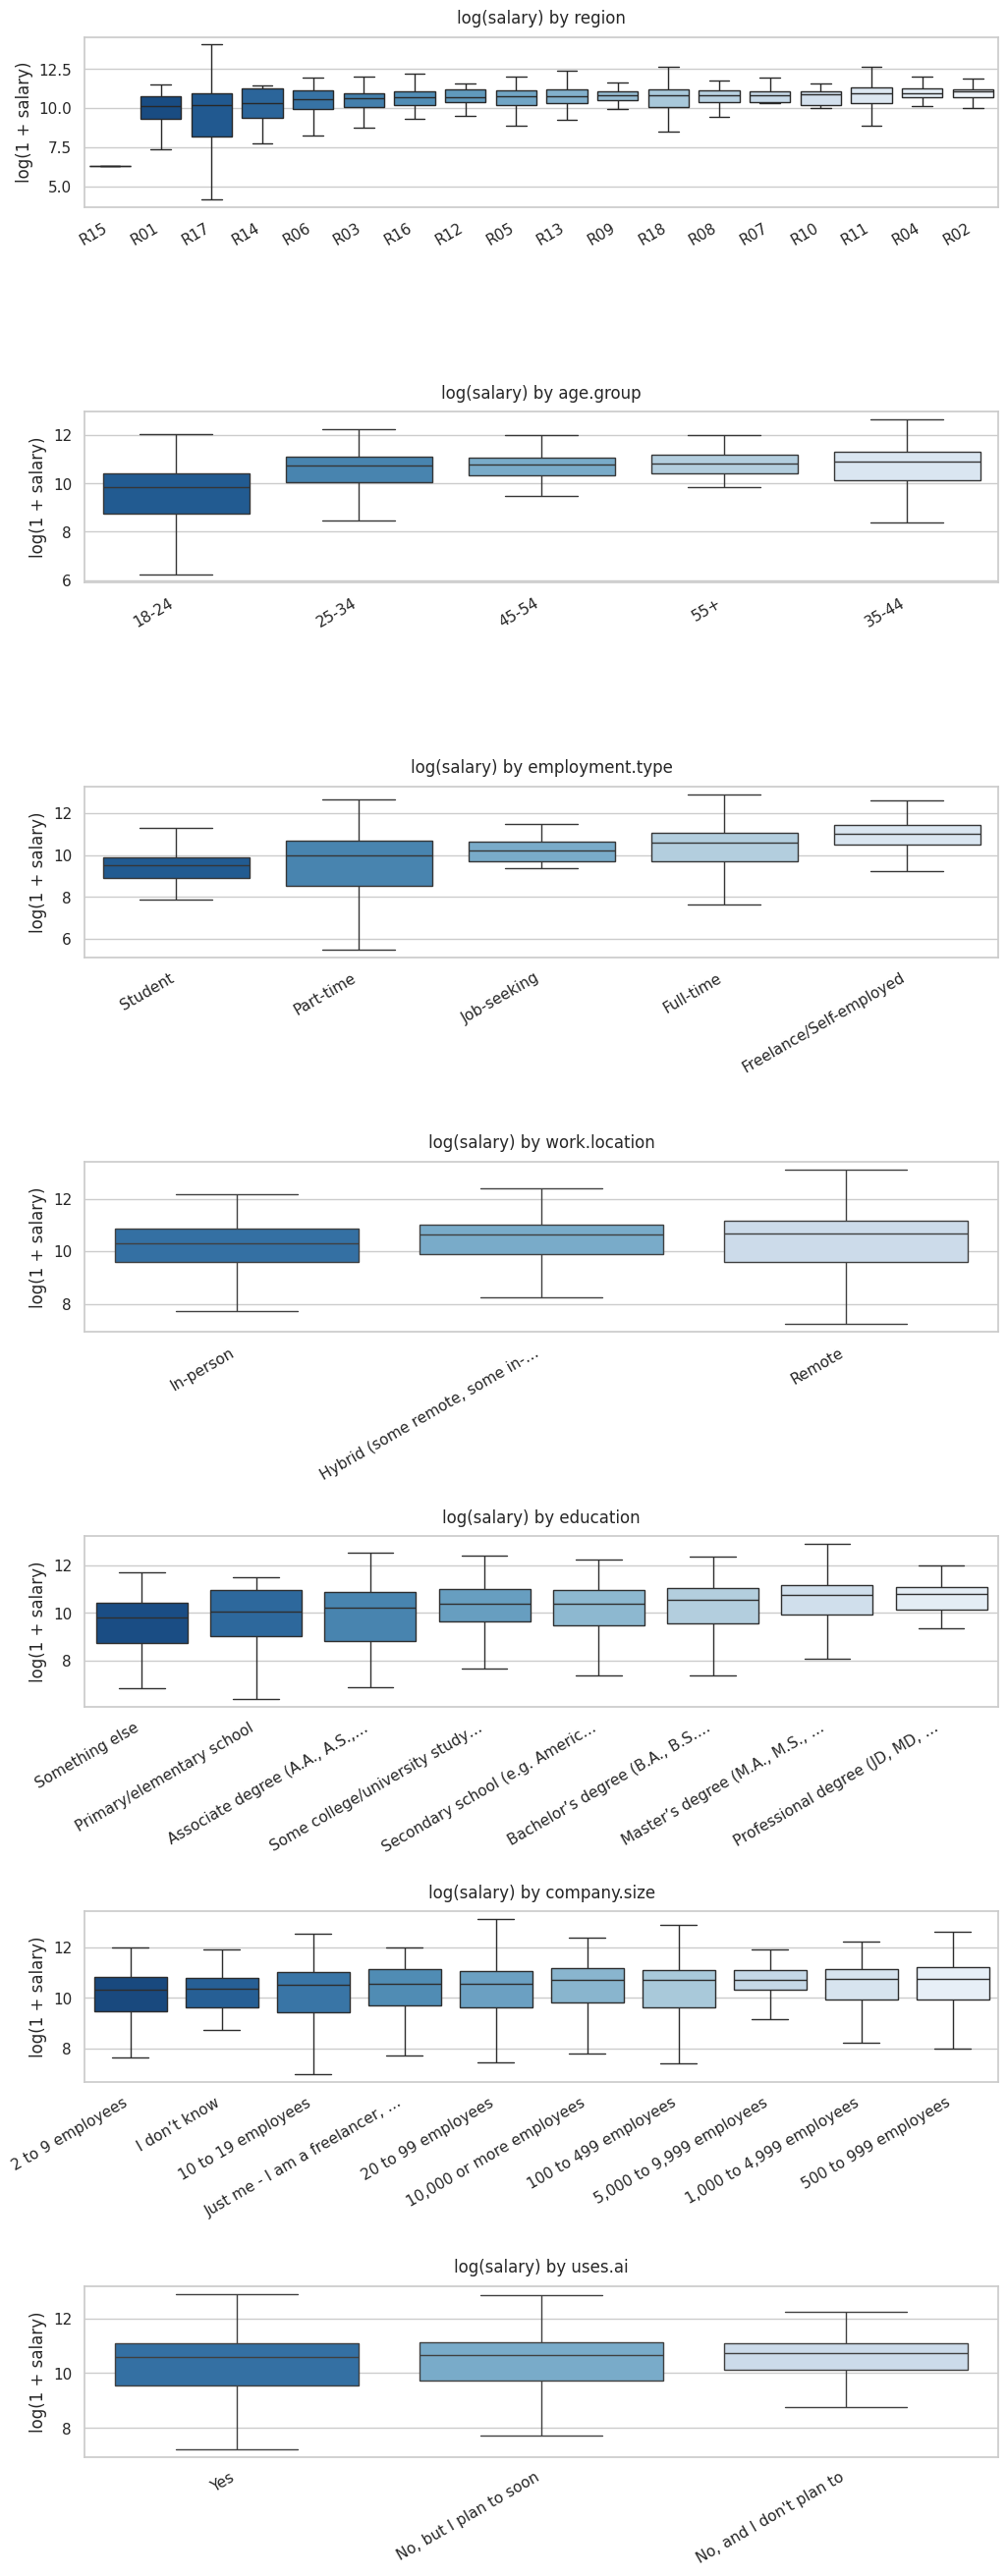

In [15]:
features_to_show = ["region", "age.group", "employment.type", "work.location",
                    "education", "company.size", "uses.ai"]


def shorten(label, n=30):
    """Truncate long category labels for plotting."""
    s = str(label)
    return s if len(s) <= n else s[: n - 1] + "…"


fig, axes = plt.subplots(7, 1, figsize=(12, 32))
plt.subplots_adjust(hspace=1.2)

for ax, col in zip(axes, features_to_show):
    # Order categories by median log-salary
    order = train.groupby(col)[target].median().sort_values().index
    sns.boxplot(data=train.assign(log_target=log_target), x=col, y="log_target",
                ax=ax, order=order, palette="Blues_r", showfliers=False)
    ax.set_title(f"log(salary) by {col}", fontsize=12, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("log(1 + salary)")
    # Shorten and rotate long labels
    short_labels = [shorten(lbl.get_text()) for lbl in ax.get_xticklabels()]
    ax.set_xticklabels(short_labels, rotation=30, ha="right")

plt.show()

### What we see

A lot of structure here:

- **`region`** has a huge range — some regions show median log-salary around 8 (≈ $3k), others around 12 (≈ $160k). This is the strongest single predictor.
- **`age.group`** matches our intuition: 18-24 earns the least, 35-54 earns the most. A weak hint of "55+" earning slightly less (semi-retirement or pre-retirement transition?).
- **`employment.type`**: Full-time earns more than Freelance/Self-employed and Part-time. As expected.
- **`work.location`**: small differences. Remote may actually earn slightly more, but the spread is large.
- **`education`**: Master's and PhD earners are clearly above the rest. Primary/elementary at the bottom (only 24 such rows, so the median is noisy).
- **`company.size`**: small companies (2-9 employees) earn less than large ones (1000+). Classic pattern.
- **`uses.ai`**: small but visible difference.

This confirms that the plain categorical features carry strong signal and will be useful in our models.

## 7. Multi-label features in action: prog.languages

To make the multi-label encoding concrete, let's pick `prog.languages` and look at how it works.

In [16]:
from sklearn.preprocessing import MultiLabelBinarizer

# Apply MultiLabelBinarizer to prog.languages
def split_tokens(series):
    return series.fillna("").astype(str).apply(lambda s: s.split(";") if s else [])

tokens = split_tokens(train["prog.languages"])
mlb = MultiLabelBinarizer()
lang_matrix = mlb.fit_transform(tokens)
lang_df = pd.DataFrame(lang_matrix, columns=[f"lang_{c}" for c in mlb.classes_])

print(f"Original prog.languages column -> {lang_df.shape[1]} binary indicators")
print(f"Top 10 most common languages:")
top10 = lang_df.sum().sort_values(ascending=False).head(10)
print(top10)

Original prog.languages column -> 40 binary indicators
Top 10 most common languages:
lang_JavaScript                 1469
lang_SQL                        1271
lang_HTML/CSS                   1173
lang_Python                     1005
lang_TypeScript                 1003
lang_Bash/Shell (all shells)     742
lang_Java                        683
lang_C#                          668
lang_C++                         432
lang_PHP                         430
dtype: int64


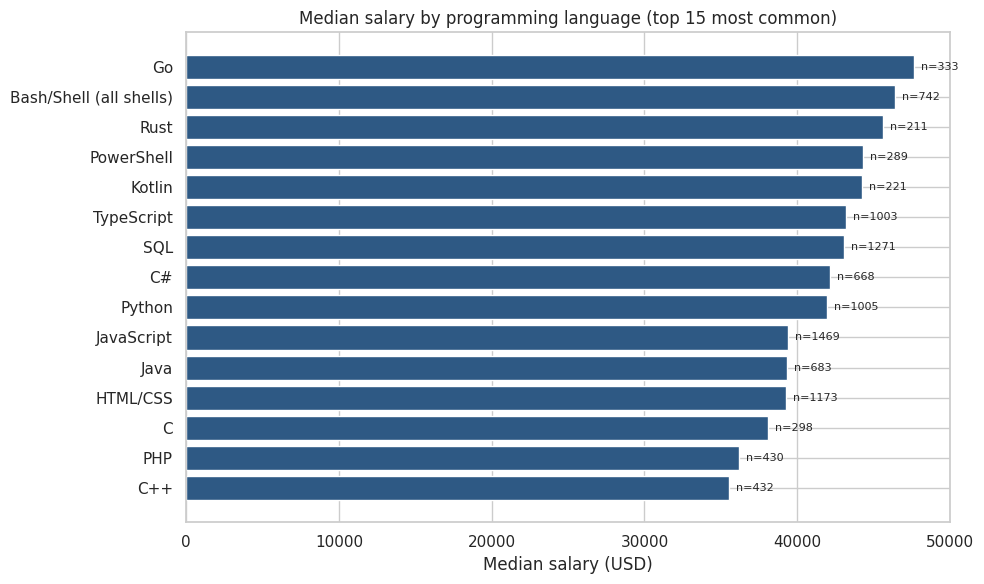

In [17]:
# Average salary by top languages (log scale)
top_langs = lang_df.sum().sort_values(ascending=False).head(15).index.tolist()
data = []
for lang in top_langs:
    mask = lang_df[lang] == 1
    median_salary = train.loc[mask, target].median()
    n = mask.sum()
    data.append({"language": lang.replace("lang_", ""), "median_salary": median_salary, "n_developers": n})
lang_summary = pd.DataFrame(data).sort_values("median_salary", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(lang_summary["language"], lang_summary["median_salary"], color="#2E5984")
ax.invert_yaxis()
ax.set_xlabel("Median salary (USD)")
ax.set_title("Median salary by programming language (top 15 most common)")
for i, row in enumerate(lang_summary.itertuples()):
    ax.text(row.median_salary, i, f"  n={row.n_developers}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

### What we see

Different programming languages are associated with very different median salaries. Some patterns:

- Languages known for backend/data engineering (Go, Rust, Scala, Kotlin) often associate with higher salaries.
- More common/general-purpose languages (PHP, HTML/CSS) often associate with lower salaries.
- The numbers above the bars (`n=...`) show how many developers in our sample listed each language. Languages with small `n` should be taken with caution.

This is exactly the kind of fine-grained signal that multi-label binarization can capture, and that plain one-hot encoding would lose. We will apply the same trick to all 15 semicolon-separated columns in the modeling notebook.

## 8. Summary — what we learned and what to do next

### Findings

1. The dataset has 2,512 training rows and 40 features — a **small dataset** by ML standards.
2. The target (annual salary) is **extremely right-skewed** (skewness 33). We will predict log-salary and convert back with `TransformedTargetRegressor`.
3. We have three types of features:
    - 4 numeric (years of coding/experience, job satisfaction)
    - 21 plain categorical (region, age, education, etc.)
    - 15 multi-label (programming languages, tools, frameworks) — these need binarization
4. After encoding, we will have around 500 features. With only 2,512 rows, **overfitting is the main risk** and we must use strong regularization.
5. Many columns have substantial missing values (especially AI-related questions and `experience.years`). We will impute.
6. The strongest predictors look like: **region**, **education**, **years of professional coding**, **age group**, **company size**, and specific **programming languages**.

### Decisions for the modeling notebook (`02_search.ipynb`)

| Step | Decision | Why |
|---|---|---|
| Metric | RMSE (Kaggle's metric) | What we are graded on |
| Target transformation | `log1p` / `expm1` via `TransformedTargetRegressor` | Target is extremely right-skewed |
| Cross-validation | `KFold(n_splits=5, shuffle=True, random_state=42)` | Standard for regression |
| Numeric features | Median imputation + StandardScaler | Robust to outliers |
| Plain categorical | Most-frequent imputation + OneHotEncoder | Standard approach for low-cardinality categoricals |
| Multi-label categorical | Custom `MultiLabelBinarizer`-based transformer | Captures individual skill tokens, not combinations |
| Algorithms to compare | **Elastic Net (regression)**, **KNN regressor**, **SVR with linear kernel** | At least 3 ML1 algorithms; cover linear, distance-based, and kernel methods |

### Risks identified

1. **Small dataset (2,512 rows) with high feature count (~500 after encoding)** — overfitting is the dominant risk. We use cross-validation carefully and rely on regularization.
2. **Multi-label encoding** is custom but standard. We will write a small reusable transformer for it.
3. **Outliers** in the target ($1 to $4.7M) — handled by the log transform.

We are now ready to start modeling. See `02_search.ipynb` for the algorithm comparison and hyperparameter tuning.